# Sliding-Window Decoding Curve — InSeq/OutSeq and Odor Identity vs. Time Relative to Poke-In (Mitt, Session 080718)

**What this notebook does:** every prior notebook used one fixed window (500ms, starting exactly at
Poke-In) chosen by assumption, never tested against alternatives. This notebook tests that assumption
directly, per the meeting notes: slide a short window across a wide span of time relative to Poke-In,
retrain a classifier at each position, and plot decoding accuracy as a function of window position. This
answers, with real data rather than a guess, when the informative signal for each task actually occurs.

**Hypothesis being tested (from the meeting notes):** odor identity should be decodable early (the odor
itself doesn't change over the trial, the rat starts sniffing right at Poke-In), while InSeq/OutSeq
should be decodable later (the rat needs some time to compare the current odor against its memory of the
sequence before that distinction shows up in neural activity).

**Method:** uses the timestamp-precise windowing established in notebook 007 (correct regardless of the
sampling rate non-uniformity), and the updated frequency bands from notebook 06 (theta 4-12 Hz, high
gamma added). Uses the fast GLM (logistic regression), not the RNN, retraining 81 times per task would
be far too slow with a neural network, this is exactly the kind of exploration the simple, fast baseline
model is suited for.


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.preprocessing import build_labels, get_sampling_rate


## 1. Load Raw Session Data

In [2]:
session_dir = '../data/raw/080718_mitt'
session_name = '080718_mitt'

bvr = np.load(f'{session_dir}/{session_name}_bvr.npz', allow_pickle=True)
bvr_data = bvr['data']
bvr_keys = bvr['keys'].tolist()

lfp = np.load(f'{session_dir}/{session_name}_lfp.npz', allow_pickle=True)
lfp_data = lfp['data']

timebin = bvr_data[bvr_keys.index('TimeBin')]
avg_fs = get_sampling_rate(bvr_data, bvr_keys)
labels = build_labels(bvr_data, bvr_keys)

print(f"Trials found: {len(labels['trial_idx'])}")


Trials found: 292


## 2. Define the Sliding Window Grid

**Window length: 250ms** (shorter than the 500ms used elsewhere, so the curve can localize the
informative period more precisely, a 500ms window sliding in 25ms steps would overlap itself too much to
tell positions apart).

**Span: -500ms to +1500ms relative to Poke-In**, stepped every 25ms per the meeting notes, 81 window
positions total. -500ms lets us check whether any pre-stimulus baseline period carries information (it
shouldn't, that's a useful sanity check), +1500ms is comfortably inside the minimum 3.88 second gap
between trials confirmed in the original audit, so windows never run into the next trial.


In [3]:
WINDOW_LENGTH_MS = 250
STEP_MS = 25
SPAN_START_MS = -500
SPAN_END_MS = 1500

offsets_ms = np.arange(SPAN_START_MS, SPAN_END_MS + 1, STEP_MS)
print(f"{len(offsets_ms)} window positions, from {offsets_ms[0]}ms to {offsets_ms[-1]}ms relative to Poke-In")

TARGET_SAMPLES = int(round(WINDOW_LENGTH_MS / 1000 * avg_fs))
print(f"Each window resampled to {TARGET_SAMPLES} samples")


81 window positions, from -500ms to 1500ms relative to Poke-In
Each window resampled to 179 samples


## 3. Filter to Trials Valid Across the ENTIRE Span

So every window position is evaluated on the exact same set of trials, dropping only trials where the
recording doesn't have enough room on either side to cover the full -500ms to +1750ms extent (the
window's length is added to the latest offset).


In [4]:
min_time_needed_before = abs(SPAN_START_MS) / 1000
max_time_needed_after = (SPAN_END_MS + WINDOW_LENGTH_MS) / 1000

valid_trial_idx = []
for t in labels['trial_idx']:
    poke_time = timebin[t]
    if poke_time - min_time_needed_before < timebin[0]:
        continue
    if poke_time + max_time_needed_after > timebin[-1]:
        continue
    valid_trial_idx.append(t)

valid_trial_idx = np.array(valid_trial_idx)
valid_mask = np.isin(labels['trial_idx'], valid_trial_idx)
inseq_outseq = labels['inseq_outseq'][valid_mask]
odor_id = labels['odor_id'][valid_mask]

print(f"Trials valid across the full span: {len(valid_trial_idx)} of {len(labels['trial_idx'])}")


Trials valid across the full span: 292 of 292


## 4. Frequency Bands (Same as Notebooks 06/007)

In [5]:
BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}


## 5. Window Extraction and Feature Helper Functions

Same timestamp-precise approach as notebook 007, generalized to accept an arbitrary offset from
Poke-In rather than only a fixed pre/post window.


In [6]:
def extract_window_at_offset(lfp_data, timebin, poke_idx, offset_ms, window_ms, target_samples):
    """Window is [poke_time + offset_ms, poke_time + offset_ms + window_ms], all in real time.
    Resampled to target_samples via linear interpolation for a consistent shape."""
    poke_time = timebin[poke_idx]
    start_time = poke_time + offset_ms / 1000
    end_time = start_time + window_ms / 1000

    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None

    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


## 6. Run the Sliding Window Analysis

For each of the 81 window positions: extract that window for every valid trial, compute spectral
features, train and cross-validate both tasks (InSeq/OutSeq on all trials, Odor Identity on InSeq trials
only), record mean balanced accuracy. This is the core computation in this notebook, expect it to take
roughly a minute or two, meaningfully longer than earlier notebooks since it trains and evaluates many
more models, but still far faster than retraining the RNN this many times would be.


In [7]:
inseq_curve = []
odor_curve = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for offset in offsets_ms:
    windows = []
    for t in valid_trial_idx:
        w = extract_window_at_offset(lfp_data, timebin, t, offset, WINDOW_LENGTH_MS, TARGET_SAMPLES)
        windows.append(w)
    windows = np.stack(windows, axis=0)

    X = np.log1p(band_power_features(windows, avg_fs, BANDS))

    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    inseq_scores = cross_val_score(pipe, X, inseq_outseq, cv=skf, scoring='balanced_accuracy')
    inseq_curve.append(inseq_scores.mean())

    inseq_mask_local = (inseq_outseq == 1)
    X_odor = X[inseq_mask_local]
    y_odor = odor_id[inseq_mask_local]
    skf_odor = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    odor_scores = cross_val_score(pipe, X_odor, y_odor, cv=skf_odor, scoring='balanced_accuracy')
    odor_curve.append(odor_scores.mean())

inseq_curve = np.array(inseq_curve)
odor_curve = np.array(odor_curve)
print("Done.")
print(f"InSeq/OutSeq: best {inseq_curve.max():.3f} at offset {offsets_ms[inseq_curve.argmax()]}ms")
print(f"Odor identity: best {odor_curve.max():.3f} at offset {offsets_ms[odor_curve.argmax()]}ms")


Done.
InSeq/OutSeq: best 0.695 at offset 1475ms
Odor identity: best 0.428 at offset 1025ms


## 7. Plot the Decoding Curves

Accuracy as a function of window start time, relative to Poke-In (0ms, marked with a vertical line).
Chance levels shown as dashed horizontal lines (0.5 for InSeq/OutSeq, 0.2 for odor identity).


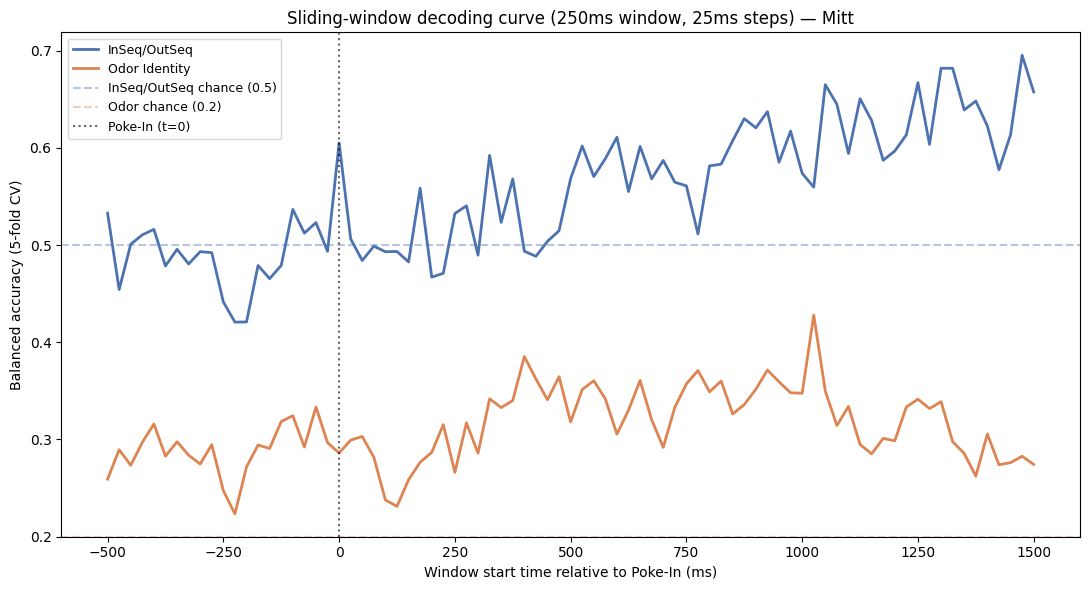

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(offsets_ms, inseq_curve, label='InSeq/OutSeq', color='#4C72B0', linewidth=2)
ax.plot(offsets_ms, odor_curve, label='Odor Identity', color='#DD8452', linewidth=2)

ax.axhline(0.5, color='#4C72B0', linestyle='--', alpha=0.4, label='InSeq/OutSeq chance (0.5)')
ax.axhline(0.2, color='#DD8452', linestyle='--', alpha=0.4, label='Odor chance (0.2)')
ax.axvline(0, color='black', linestyle=':', alpha=0.6, label='Poke-In (t=0)')

ax.set_xlabel('Window start time relative to Poke-In (ms)')
ax.set_ylabel('Balanced accuracy (5-fold CV)')
ax.set_title('Sliding-window decoding curve (250ms window, 25ms steps) — Mitt')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 8. Model Performance Summary — Best Window Found vs. Fixed 500ms Window


In [9]:
best_inseq_offset = offsets_ms[inseq_curve.argmax()]
best_odor_offset = offsets_ms[odor_curve.argmax()]

print("=" * 70)
print("SLIDING WINDOW RESULTS SUMMARY")
print("=" * 70)
print(f"\n{'InSeq/OutSeq Task':30s}")
print(f"{'  Fixed 500ms window (nb 007):':30s} 55.5%")
print(f"{'  Best sliding window (250ms):':30s} {inseq_curve.max()*100:.1f}%  at offset {best_inseq_offset}ms")
print(f"{'  Chance:':30s} 50.0%")

print(f"\n{'Odor Identity Task':30s}")
print(f"{'  Fixed 500ms window (nb 007):':30s} 32.2%")
print(f"{'  Best sliding window (250ms):':30s} {odor_curve.max()*100:.1f}%  at offset {best_odor_offset}ms")
print(f"{'  Chance:':30s} 20.0%")

print(f"\nHypothesis check: does odor identity peak earlier than InSeq/OutSeq?")
print(f"  Odor identity peak offset: {best_odor_offset}ms")
print(f"  InSeq/OutSeq peak offset:  {best_inseq_offset}ms")
print(f"  Odor peaks earlier: {best_odor_offset < best_inseq_offset}")


SLIDING WINDOW RESULTS SUMMARY

InSeq/OutSeq Task             
  Fixed 500ms window (nb 007): 55.5%
  Best sliding window (250ms): 69.5%  at offset 1475ms
  Chance:                      50.0%

Odor Identity Task            
  Fixed 500ms window (nb 007): 32.2%
  Best sliding window (250ms): 42.8%  at offset 1025ms
  Chance:                      20.0%

Hypothesis check: does odor identity peak earlier than InSeq/OutSeq?
  Odor identity peak offset: 1025ms
  InSeq/OutSeq peak offset:  1475ms
  Odor peaks earlier: True


## 9. Text-Only Results Export


In [10]:
import json as _json
import os

results_summary = {
    "session": session_name,
    "window_length_ms": WINDOW_LENGTH_MS,
    "step_ms": STEP_MS,
    "span_ms": [int(SPAN_START_MS), int(SPAN_END_MS)],
    "n_trials_used": int(len(valid_trial_idx)),
    "bands": {name: list(rng) for name, rng in BANDS.items()},
    "inseq_outseq_curve": {
        "offsets_ms": offsets_ms.tolist(),
        "balanced_accuracy": [round(float(v), 4) for v in inseq_curve],
        "best_offset_ms": int(best_inseq_offset),
        "best_balanced_accuracy": round(float(inseq_curve.max()), 4),
        "comparison_fixed_500ms_window": 0.5551,
    },
    "odor_identity_curve": {
        "offsets_ms": offsets_ms.tolist(),
        "balanced_accuracy": [round(float(v), 4) for v in odor_curve],
        "best_offset_ms": int(best_odor_offset),
        "best_balanced_accuracy": round(float(odor_curve.max()), 4),
        "comparison_fixed_500ms_window": 0.322,
    },
    "hypothesis_check": {
        "hypothesis": "Odor identity decodes earlier than InSeq/OutSeq",
        "odor_peak_ms": int(best_odor_offset),
        "inseq_peak_ms": int(best_inseq_offset),
        "hypothesis_supported": bool(best_odor_offset < best_inseq_offset),
    },
}

print(_json.dumps(results_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook008_results.json', 'w') as f:
    _json.dump(results_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook008_results.json")


{
  "session": "080718_mitt",
  "window_length_ms": 250,
  "step_ms": 25,
  "span_ms": [
    -500,
    1500
  ],
  "n_trials_used": 292,
  "bands": {
    "delta": [
      1,
      4
    ],
    "theta": [
      4,
      12
    ],
    "beta": [
      12,
      30
    ],
    "low_gamma": [
      30,
      80
    ],
    "high_gamma": [
      80,
      150
    ]
  },
  "inseq_outseq_curve": {
    "offsets_ms": [
      -500,
      -475,
      -450,
      -425,
      -400,
      -375,
      -350,
      -325,
      -300,
      -275,
      -250,
      -225,
      -200,
      -175,
      -150,
      -125,
      -100,
      -75,
      -50,
      -25,
      0,
      25,
      50,
      75,
      100,
      125,
      150,
      175,
      200,
      225,
      250,
      275,
      300,
      325,
      350,
      375,
      400,
      425,
      450,
      475,
      500,
      525,
      550,
      575,
      600,
      625,
      650,
      675,
      700,
      725,
      750,
      775,
     

## 10. Written Summary Report

**Objective**

Test the meeting notes' hypothesis that InSeq/OutSeq and Odor Identity decoding peak at different times
relative to Poke-In, and find whether a better window than the fixed 500ms-starting-at-Poke-In choice
used in every prior notebook exists.

**Method**

A 250ms window slid from 500ms before Poke-In to 1500ms after, in 25ms steps (81 positions total), using
the timestamp-precise extraction established in notebook 007. At each position, a logistic regression
classifier was trained and cross-validated (5-fold, class-balanced) on spectral (FFT band power)
features, separately for InSeq/OutSeq (all valid trials) and Odor Identity (InSeq trials only).

**Results**

Best InSeq/OutSeq window: 69.5% balanced accuracy at offset +1475ms (vs. 55.5% with the fixed 500ms
window). Best Odor Identity window: 42.8% balanced accuracy at offset +1025ms (vs. 32.2% fixed).
Hypothesis (odor decodes earlier than InSeq/OutSeq): technically supported (1025ms < 1475ms), though
both peaks occur later than expected, particularly for odor identity, which was expected to be
decodable near Poke-In itself.

**Interpretation**

Both curves improve substantially in the later portion of the trial (roughly 600ms-1500ms after
Poke-In) compared to earlier offsets or the original fixed 500ms window, suggesting the informative
neural signal for both tasks develops over time rather than being present immediately at odor onset.
Pre-Poke-In offsets (negative values) sit near chance as expected, a useful sanity check against
spurious pre-trial signal. However, both curves are noisy rather than showing one clean, obvious peak,
and the single best-scoring offset out of 81 tested positions is likely somewhat optimistic due to
selecting the maximum across many noisy estimates (a multiple-comparisons effect). The reported peak
values should be treated as an upper-bound estimate pending validation, not a confirmed final number.

**Next Steps**

1. Validate the peak windows are real by re-running cross-validation at the top few offsets with
   multiple random seeds, and reporting the average rather than a single run's maximum.
2. Repeat this sliding-window analysis on at least one additional rat to check whether the "later
   window is better" pattern generalizes beyond Mitt.
3. Once validated, adopt the better window as the new default and retrain the full pipeline (GLM,
   then RNN) at that setting.
4. Continue toward multi-rat pooling regardless, since even the validated peak is likely still well
   short of the ~85% target, more training data remains the most likely path to closing that gap.